# Regression Tree Diagnosis

Load a saved tree and inspect optimizer behavior at high-error or rejected nodes. `fit_error` is the node training error measured with the stopping metric recorded in the run configuration.

In [1]:
from collections import Counter
from pathlib import Path
from pprint import pprint
import sys

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "art").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from art.models import MODEL_CONDITION_WARNING_THRESHOLD
from art.tree import LeafNode, RegressionTree

In [2]:
ARTIFACT_PATH = (
    PROJECT_ROOT
    / "examples"
    / "tree_2d_benchmark_outputs"
    / "spherical_piecewise"
    / "ptwise_deg1"
 #   / "dim_5"
    / "tree.joblib"
)

tree, run_config = RegressionTree.load(ARTIFACT_PATH)
nodes = list(tree.iter_nodes())
leaves = list(tree.iter_leaves())
error_metric = run_config.get("arguments", {}).get(
    "error_metric", tree.metadata.get("error_metric", "fit_error")
)

max_depth = run_config.get("arguments", {}).get("max_depth", tree.metadata.get("max_depth", None))

print(f"artifact: {ARTIFACT_PATH}")
print(f"nodes: {len(nodes)} | leaves: {len(leaves)}")
print(f"fit_error metric: {error_metric}")
print(f"max_depth: {max_depth}")

artifact: /Users/ssubramanian/Research/Adaptive Regression Tree/examples/tree_2d_benchmark_outputs/spherical_piecewise/ptwise_deg1/tree.joblib
nodes: 4243 | leaves: 2122
fit_error metric: max_pointwise_relative
max_depth: 15


In [3]:
# utils

def select_nodes(
    tree,
    *,
    status=None,
    warning=None,
    depth=None,
    node_kind=None,
    k=1,
    criterion="fit_error",
    random_state=None,
):
    """Filter tree nodes and return the worst or a random selection."""

    if node_kind not in (None, "leaf", "split"):
        raise ValueError("node_kind must be None, 'leaf', or 'split'.")
    if criterion not in ("fit_error", "fit_mse", "random"):
        raise ValueError("criterion must be 'fit_error', 'fit_mse', or 'random'.")
    if not isinstance(k, (int, np.integer)) or k < 1:
        raise ValueError("k must be a positive integer.")
    if depth is not None and (
        not isinstance(depth, (int, np.integer)) or depth < 0
    ):
        raise ValueError("depth must be a nonnegative integer or None.")

    statuses = (
        None
        if status is None
        else ({status} if isinstance(status, str) else set(status))
    )
    warnings = (
        None
        if warning is None
        else ({warning} if isinstance(warning, str) else set(warning))
    )
    candidates = []
    for node in tree.iter_nodes():
        is_leaf = isinstance(node, LeafNode)
        if statuses is not None and node.status not in statuses:
            continue
        if depth is not None and node.depth != depth:
            continue
        if node_kind == "leaf" and not is_leaf:
            continue
        if node_kind == "split" and is_leaf:
            continue
        node_warnings = set(node.metadata.get("warnings", ()))
        node_warnings.update(node.metadata.get("sampling_warnings", ()))
        if warnings is not None and node_warnings.isdisjoint(warnings):
            continue
        candidates.append(node)

    if criterion == "random":
        if not candidates:
            return []
        rng = (
            random_state
            if isinstance(random_state, np.random.Generator)
            else np.random.default_rng(random_state)
        )
        indices = rng.choice(
            len(candidates), size=min(k, len(candidates)), replace=False
        )
        return [candidates[int(index)] for index in np.atleast_1d(indices)]

    scored = []
    for node in candidates:
        value = node.metadata.get(criterion)
        if value is not None and np.isfinite(value):
            scored.append((float(value), node))
    scored.sort(key=lambda item: (-item[0], item[1].node_id))
    return [node for _, node in scored[:k]]


def plot_node_error_path(node, log_scale=True):
    path = tree.path_to_node(node.node_id)
    depths = np.asarray([path_node.depth for path_node in path], dtype=int)
    fit_errors = np.asarray(
        [path_node.metadata.get("fit_error", np.nan) for path_node in path],
        dtype=float,
    )
    fit_mses = np.asarray(
        [path_node.metadata.get("fit_mse", np.nan) for path_node in path],
        dtype=float,
    )
    metric_name = node.metadata.get("fit_error_metric", error_metric)

    fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
    series = (
        (fit_errors, f"Fit error ({metric_name})"),
        (fit_mses, "Fit MSE"),
    )
    for axis, (values, title) in zip(axes, series):
        axis.plot(depths, values, marker="o")
        if np.isfinite(values[-1]):
            axis.scatter(
                depths[-1],
                values[-1],
                color="tab:red",
                marker="*",
                s=120,
                zorder=3,
                label="requested node",
            )
        finite_values = values[np.isfinite(values)]
        if log_scale and finite_values.size and np.all(finite_values > 0.0):
            axis.set_yscale("log")
        axis.set(title=title, ylabel="error")
        axis.grid(True, alpha=0.25)
        if axis.get_legend_handles_labels()[0]:
            axis.legend()

    axes[-1].set_xlabel("tree depth")
    axes[-1].set_xticks(depths)
    fig.suptitle(f"Root-to-node error path: {node.node_id} | {node.status}")
    fig.tight_layout()
    plt.show()
    return fig, axes


def plot_node_optimizer_diagnostics(node):
    diagnostics = node.metadata.get("splitter_metadata", {})
    loss = np.asarray(diagnostics.get("soft_loss_history", ()), dtype=float)
    line_search_loss = np.asarray(
        diagnostics.get("line_search_loss_history", ()), dtype=float
    )
    grad = np.asarray(
        diagnostics.get("projected_grad_norm_history", ()), dtype=float
    )
    backtracks = np.asarray(diagnostics.get("backtrack_history", ()), dtype=float)
    step_sizes = np.asarray(diagnostics.get("step_size_history", ()), dtype=float)

    print(
        {
            "node_id": node.node_id,
            "depth": node.depth,
            "status": node.status,
            "fit_error_metric": node.metadata.get("fit_error_metric", error_metric),
            "fit_error": node.metadata.get("fit_error"),
            "fit_mse": node.metadata.get("fit_mse"),
            "restarts_on_failure": node.metadata.get("restarts_on_failure", 0),
            "attempt_failure_reasons": node.metadata.get(
                "split_attempt_failure_reasons", ()
            ),
            "optimizer_stop_reason": diagnostics.get("stop_reason"),
        }
    )

    fig, axes = plt.subplots(1, 3, figsize=(14, 5))

    if loss.size:
        axes[0].plot(np.arange(loss.size), loss, marker="o", label="refitted loss")
    if line_search_loss.size:
        axes[0].plot(
            np.arange(1, line_search_loss.size + 1),
            line_search_loss,
            marker=".",
            label="line-search loss",
        )
    if loss.size and np.all(loss > 0.0):
        axes[0].set_yscale("log")
    axes[0].set(title="Soft objective", xlabel="iteration", ylabel="loss")
    axes[0].legend()

    if grad.size:
        axes[1].plot(np.arange(grad.size), grad, marker="o")
    grad_tolerance = diagnostics.get("grad_tolerance")
    if grad_tolerance is not None and np.isfinite(grad_tolerance):
        axes[1].axhline(grad_tolerance, color="tab:red", linestyle="--", label="tolerance")
        axes[1].legend()
    if grad.size and np.all(grad > 0.0):
        axes[1].set_yscale("log")
    axes[1].set(
        title="Projected gradient norm",
        xlabel="iteration",
        ylabel="norm",
    )

    accepted_iterations = np.arange(1, backtracks.size + 1)
    if backtracks.size:
        axes[2].bar(accepted_iterations, backtracks, alpha=0.65, label="backtracks")
    axes[2].set(
        title="Armijo behavior",
        xlabel="accepted iteration",
        ylabel="backtrack count",
    )
    if step_sizes.size:
        step_axis = axes[2].twinx()
        step_axis.plot(
            np.arange(1, step_sizes.size + 1),
            step_sizes,
            color="tab:red",
            marker=".",
            label="accepted step",
        )
        if np.all(step_sizes > 0.0):
            step_axis.set_yscale("log")
        step_axis.set_ylabel("accepted step size", color="tab:red")

    for axis in axes:
        axis.grid(True, alpha=0.25)
    fig.suptitle(
        f"{node.node_id} | {node.status} | {error_metric}={node.metadata['fit_error']:.4e}"
    )
    fig.tight_layout()
    plt.show()

In [4]:
def plot_node_solver_diagnostics(node):
    """Print and plot regression-solver diagnostics for one node."""

    metadata = node.metadata
    diagnostics = metadata.get("splitter_metadata", {})
    arguments = run_config.get("arguments", {})
    warning_threshold = tree.metadata.get(
        "model_condition_warning_threshold",
        MODEL_CONDITION_WARNING_THRESHOLD,
    )
    auto_mode = (
        arguments.get("ridge_solver") == "auto"
        or metadata.get("fit_solver_requested") == "auto"
    )
    auto_rcond_threshold = (
        arguments.get("auto_rcond_threshold") if auto_mode else None
    )
    auto_condition_cutoff = (
        None
        if auto_rcond_threshold is None
        else float(auto_rcond_threshold) ** -0.5
    )

    solve_fields = (
        "solver_requested",
        "solver_used",
        "condition_estimator",
        "cond_estimate",
        "ridge_effective",
        "rank",
        "fallback_reason",
    )

    def solve_summary(solve):
        if not isinstance(solve, dict):
            return None
        return {field: solve.get(field) for field in solve_fields}

    node_fit = {
        "solver_requested": metadata.get("fit_solver_requested"),
        "solver_used": metadata.get("fit_solver_used"),
        "condition_estimator": metadata.get("fit_condition_estimator"),
        "cond_estimate": metadata.get("fit_cond_estimate"),
        "ridge_effective": metadata.get("fit_ridge_effective"),
        "rank": metadata.get("fit_rank"),
        "fallback_reason": metadata.get("fit_fallback_reason"),
    }
    if all(value is None for value in node_fit.values()):
        node_fit = solve_summary(diagnostics.get("parent_solve"))

    final_soft = diagnostics.get("final_soft_metadata", {})
    if not isinstance(final_soft, dict):
        final_soft = {}

    def condition_history(key):
        return np.asarray(
            [
                np.nan if value is None else float(value)
                for value in diagnostics.get(key, ())
            ],
            dtype=float,
        )

    left_condition = condition_history("left_cond_estimate_history")
    right_condition = condition_history("right_cond_estimate_history")
    left_solvers = tuple(diagnostics.get("left_solver_history", ()))
    right_solvers = tuple(diagnostics.get("right_solver_history", ()))

    def history_summary(values, estimator_key, solvers):
        observed = values[~np.isnan(values)]
        estimators = tuple(
            sorted(
                {
                    str(value)
                    for value in diagnostics.get(estimator_key, ())
                    if value is not None
                }
            )
        )
        return {
            "initial_condition": (
                None
                if values.size == 0 or np.isnan(values[0])
                else float(values[0])
            ),
            "final_condition": (
                None
                if values.size == 0 or np.isnan(values[-1])
                else float(values[-1])
            ),
            "max_condition": (
                None if observed.size == 0 else float(np.max(observed))
            ),
            "missing_estimates": int(np.sum(np.isnan(values))),
            "infinite_estimates": int(np.sum(np.isinf(values))),
            "condition_estimators": estimators,
            "solver_counts": dict(Counter(solvers)),
        }

    summary = {
        "node": {
            "node_id": node.node_id,
            "depth": node.depth,
            "status": node.status,
            "warnings": metadata.get("warnings", ()),
        },
        "sampling": {
            "method": metadata.get("sampling_method"),
            "covariance_condition_number": metadata.get(
                "sampling_covariance_condition_number"
            ),
            "covariance_floor_saturated": metadata.get(
                "sampling_covariance_floor_saturated"
            ),
            "warnings": metadata.get("sampling_warnings", ()),
        },
        "thresholds": {
            "auto_rcond_threshold": auto_rcond_threshold,
            "auto_condition_cutoff": auto_condition_cutoff,
            "condition_warning_threshold": warning_threshold,
        },
        "node_fit": node_fit,
        "final_soft_left": solve_summary(final_soft.get("left_solve")),
        "final_soft_right": solve_summary(final_soft.get("right_solve")),
        "hard_left": solve_summary(diagnostics.get("hard_left_solve")),
        "hard_right": solve_summary(diagnostics.get("hard_right_solve")),
        "left_history": history_summary(
            left_condition, "left_condition_estimator_history", left_solvers
        ),
        "right_history": history_summary(
            right_condition, "right_condition_estimator_history", right_solvers
        ),
    }
    pprint(summary, sort_dicts=False)

    has_condition_history = any(
        np.any(np.isfinite(values) & (values > 0.0))
        for values in (left_condition, right_condition)
    )
    has_solver_history = bool(left_solvers or right_solvers)
    if not has_condition_history and not has_solver_history:
        print("No iterative condition or solver histories were recorded.")
        return summary, None, None

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    condition_axis, solver_axis = axes
    for label, values, color in (
        ("left", left_condition, "tab:blue"),
        ("right", right_condition, "tab:orange"),
    ):
        if values.size:
            plottable = np.where(
                np.isfinite(values) & (values > 0.0), values, np.nan
            )
            if np.any(np.isfinite(plottable)):
                condition_axis.plot(
                    np.arange(values.size),
                    plottable,
                    marker=".",
                    color=color,
                    label=label,
                )
    if auto_condition_cutoff is not None:
        condition_axis.axhline(
            auto_condition_cutoff,
            color="tab:green",
            linestyle="--",
            label="auto QR cutoff",
        )
    condition_axis.axhline(
        warning_threshold,
        color="tab:red",
        linestyle=":",
        label="conditioning warning",
    )
    condition_axis.set_yscale("log")
    condition_axis.set(
        title="Soft-model conditioning",
        xlabel="accepted iteration",
        ylabel="condition estimate",
    )
    condition_axis.grid(True, alpha=0.25)
    condition_axis.legend()

    solver_codes = {"cholesky": 0, "qr": 1, "svd": 2}
    for label, solvers, offset, color in (
        ("left", left_solvers, -0.06, "tab:blue"),
        ("right", right_solvers, 0.06, "tab:orange"),
    ):
        if solvers:
            codes = np.asarray(
                [solver_codes.get(value, np.nan) for value in solvers],
                dtype=float,
            )
            solver_axis.step(
                np.arange(codes.size),
                codes + offset,
                where="mid",
                marker=".",
                color=color,
                label=label,
            )
    if has_solver_history:
        solver_axis.set_yticks(
            list(solver_codes.values()), labels=list(solver_codes)
        )
        solver_axis.legend()
    else:
        solver_axis.text(
            0.5,
            0.5,
            "Per-iteration solver history is not stored for fixed solvers.",
            ha="center",
            va="center",
            transform=solver_axis.transAxes,
            wrap=True,
        )
    solver_axis.set(
        title="Selected soft-model solvers",
        xlabel="accepted iteration",
    )
    solver_axis.grid(True, alpha=0.25)

    fig.suptitle(f"Solver diagnostics: {node.node_id} | {node.status}")
    fig.tight_layout()
    plt.show()
    return summary, fig, axes

## Maximum-error leaf path

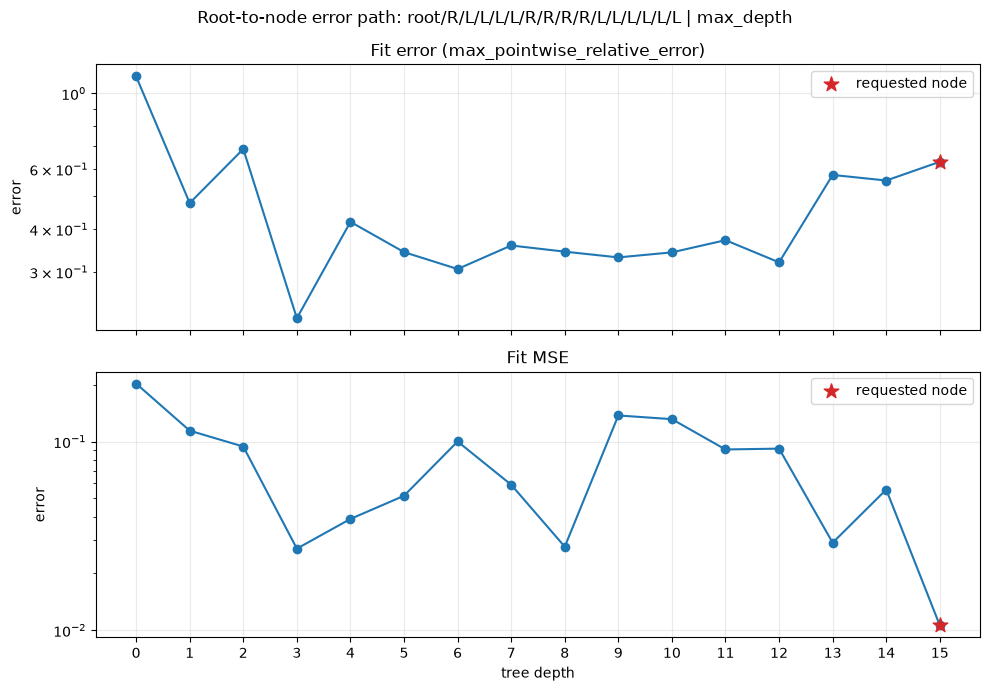

{}


In [5]:
maximum_error_leaf = select_nodes(tree, node_kind="leaf")[0]
plot_node_error_path(maximum_error_leaf)

diagnostics = maximum_error_leaf.metadata.get("splitter_metadata", {})
print(diagnostics)

## Worst `min_side_points` node

{'node_id': 'root/R/L/R/R/R/L/L/L/L/R/R/R/R', 'depth': 13, 'status': 'min_side_points', 'fit_error_metric': 'max_pointwise_relative_error', 'fit_error': 0.44484567460116853, 'fit_mse': 0.00469623767017224, 'restarts_on_failure': 3, 'attempt_failure_reasons': ('min_side_points', 'min_side_points', 'min_side_points', 'min_side_points'), 'optimizer_stop_reason': 'max_iters'}


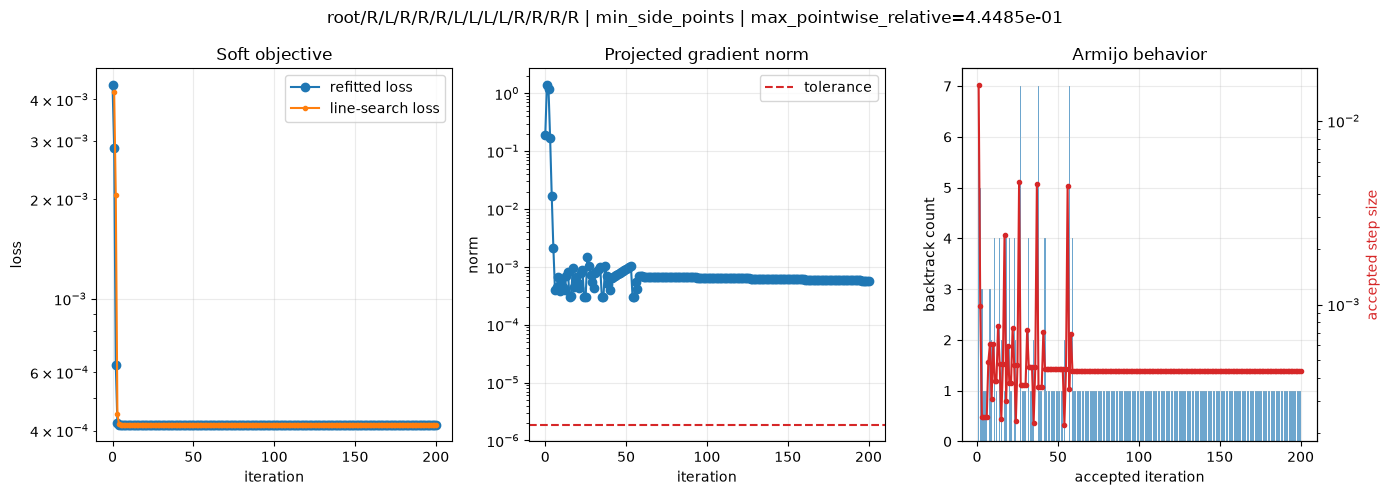

{'node': {'node_id': 'root/R/L/R/R/R/L/L/L/L/R/R/R/R',
          'depth': 13,
          'status': 'min_side_points',
          'warnings': ()},
 'sampling': {'method': 'isotropic_hit_and_run',
              'covariance_condition_number': 1.9242621938699358,
              'covariance_floor_saturated': False,
              'warnings': ()},
 'thresholds': {'auto_rcond_threshold': 1e-10,
                'auto_condition_cutoff': 100000.0,
                'condition_warning_threshold': 10000000000.0},
 'node_fit': {'solver_requested': 'auto',
              'solver_used': 'cholesky',
              'condition_estimator': 'sqrt_gram_1norm',
              'cond_estimate': 4368.167836764624,
              'ridge_effective': 0.0,
              'rank': None,
              'fallback_reason': None},
 'final_soft_left': {'solver_requested': 'auto',
                     'solver_used': 'cholesky',
                     'condition_estimator': 'sqrt_gram_1norm',
                     'cond_estimate': 4511.1

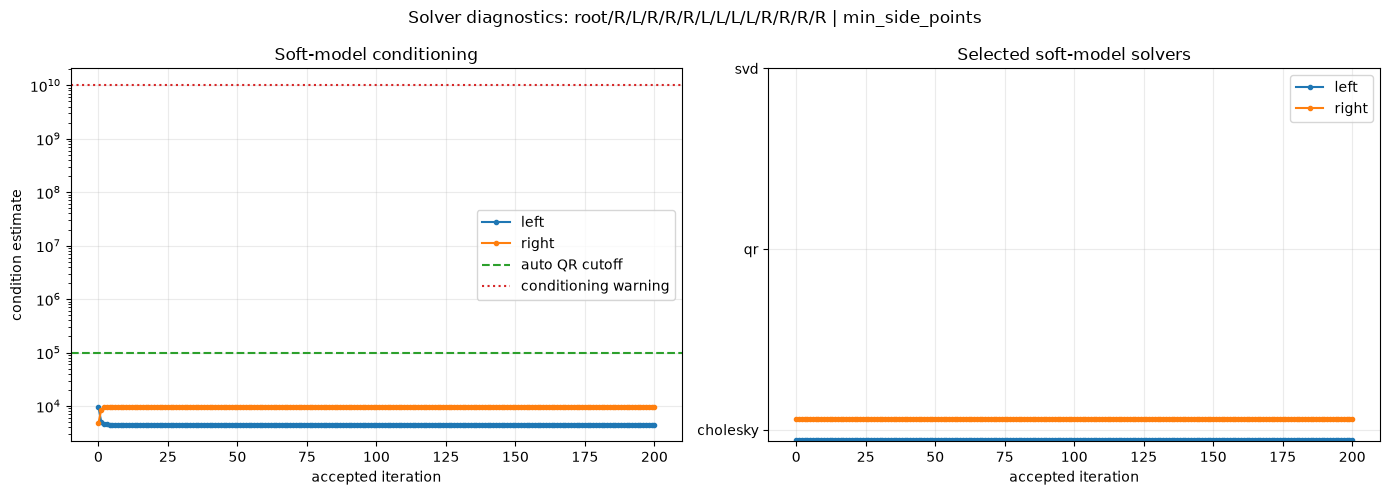

In [6]:
min_side_nodes = select_nodes(
    tree, status="min_side_points", node_kind="leaf"
)
if not min_side_nodes:
    print("No node has status 'min_side_points'.")
else:
    worst_min_side_node = min_side_nodes[0]
    plot_node_optimizer_diagnostics(worst_min_side_node)
    plot_node_solver_diagnostics(worst_min_side_node)

## Worst `insufficient_split_gain` node

In [7]:
gain_nodes = select_nodes(
    tree,
    status=("insufficient_split_gain", "insufficient_relative_split_gain"),
    node_kind="leaf",
)
if not gain_nodes:
    print("No node has an insufficient split-gain status.")
else:
    worst_gain_node = gain_nodes[0]
    plot_node_optimizer_diagnostics(worst_gain_node)
    plot_node_solver_diagnostics(worst_gain_node)

No node has an insufficient split-gain status.


## Worst `max_iters` warning

{'node_id': 'root/R/R/R/R/L/R/L/R/R/R/L/L', 'depth': 12, 'status': 'split_with_warnings', 'fit_error_metric': 'max_pointwise_relative_error', 'fit_error': 0.2950542457468552, 'fit_mse': 0.18096945350980073, 'restarts_on_failure': 0, 'attempt_failure_reasons': (), 'optimizer_stop_reason': 'max_iters'}


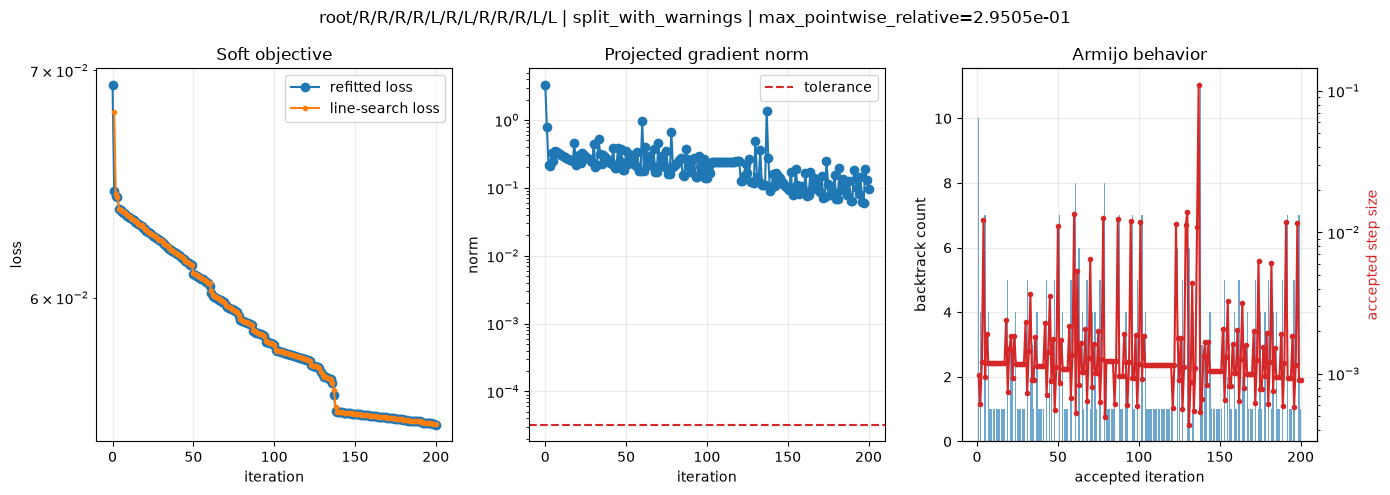

{'node': {'node_id': 'root/R/R/R/R/L/R/L/R/R/R/L/L',
          'depth': 12,
          'status': 'split_with_warnings',
          'warnings': ('max_iters',)},
 'sampling': {'method': 'isotropic_hit_and_run',
              'covariance_condition_number': 3.681909667577928,
              'covariance_floor_saturated': False,
              'warnings': ()},
 'thresholds': {'auto_rcond_threshold': 1e-10,
                'auto_condition_cutoff': 100000.0,
                'condition_warning_threshold': 10000000000.0},
 'node_fit': {'solver_requested': 'auto',
              'solver_used': 'cholesky',
              'condition_estimator': 'sqrt_gram_1norm',
              'cond_estimate': 492.6004782298332,
              'ridge_effective': 0.0,
              'rank': None,
              'fallback_reason': None},
 'final_soft_left': {'solver_requested': 'auto',
                     'solver_used': 'cholesky',
                     'condition_estimator': 'sqrt_gram_1norm',
                     'cond_esti

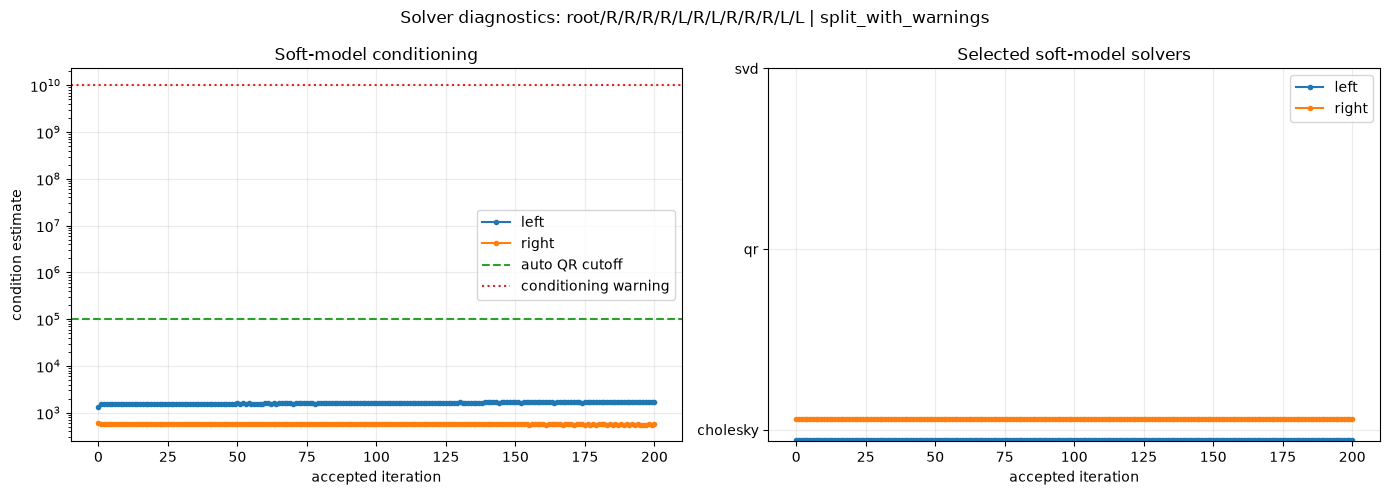

In [8]:
max_iter_nodes = select_nodes(tree, warning="max_iters", criterion = "fit_mse", k=1)
if not max_iter_nodes:
    print("No node has warning 'max_iters'.")
else:
    worst_max_iter_node = max_iter_nodes[0]
    plot_node_optimizer_diagnostics(worst_max_iter_node)
    plot_node_solver_diagnostics(worst_max_iter_node)

## Worst `high_model_conditioning` warning

In [9]:
high_condition_nodes = select_nodes(
    tree, warning="high_model_conditioning"
)
if not high_condition_nodes:
    print("No node has warning 'high_model_conditioning'.")
else:
    worst_high_condition_node = high_condition_nodes[0]
    if worst_high_condition_node.metadata.get("splitter_metadata"):
        plot_node_optimizer_diagnostics(worst_high_condition_node)
    else:
        print("No optimizer diagnostics were recorded for this node.")
    plot_node_solver_diagnostics(worst_high_condition_node)

No node has warning 'high_model_conditioning'.


## Worst covariance eigenvalue-floor saturation warning

In [10]:
covariance_floor_nodes = select_nodes(
    tree, warning="covariance_eigenvalue_floor_saturated"
)
if not covariance_floor_nodes:
    print(
        "No node has sampling warning "
        "'covariance_eigenvalue_floor_saturated'."
    )
else:
    worst_covariance_floor_node = covariance_floor_nodes[0]
    if worst_covariance_floor_node.metadata.get("splitter_metadata"):
        plot_node_optimizer_diagnostics(worst_covariance_floor_node)
    else:
        print("No optimizer diagnostics were recorded for this node.")
    plot_node_solver_diagnostics(worst_covariance_floor_node)

No optimizer diagnostics were recorded for this node.
{'node': {'node_id': 'root/R/L/R/L/L/L/R/R/L/R/R/R/R/R/L',
          'depth': 15,
          'status': 'max_depth',
          'warnings': ()},
 'sampling': {'method': 'isotropic_hit_and_run',
              'covariance_condition_number': 199.01866165411695,
              'covariance_floor_saturated': True,
              'warnings': ('covariance_eigenvalue_floor_saturated',)},
 'thresholds': {'auto_rcond_threshold': 1e-10,
                'auto_condition_cutoff': 100000.0,
                'condition_warning_threshold': 10000000000.0},
 'node_fit': {'solver_requested': 'auto',
              'solver_used': 'cholesky',
              'condition_estimator': 'sqrt_gram_1norm',
              'cond_estimate': 26270.904005031483,
              'ridge_effective': 0.0,
              'rank': None,
              'fallback_reason': None},
 'final_soft_left': None,
 'final_soft_right': None,
 'hard_left': None,
 'hard_right': None,
 'left_history': {

## Worst `small_init_grad` warning

In [11]:
small_init_grad_nodes = select_nodes(tree, warning="small_init_grad")
if not small_init_grad_nodes:
    print("No node has warning 'small_init_grad'.")
else:
    worst_small_init_grad_node = small_init_grad_nodes[0]
    plot_node_optimizer_diagnostics(worst_small_init_grad_node)
    plot_node_solver_diagnostics(worst_small_init_grad_node)

No node has warning 'small_init_grad'.


## Worst `tolerance_met` leaf

In [12]:
tolerance_nodes = select_nodes(
    tree, status="tolerance_met", node_kind="leaf"
)
if not tolerance_nodes:
    print("No leaf has status 'tolerance_met'.")
else:
    worst_tolerance_node = tolerance_nodes[0]
    print(
        "No optimizer diagnostics exist because this node met tolerance "
        "before splitting."
    )
    plot_node_solver_diagnostics(worst_tolerance_node)

No optimizer diagnostics exist because this node met tolerance before splitting.
{'node': {'node_id': 'root/R/R/R/L/L/L',
          'depth': 6,
          'status': 'tolerance_met',
          'warnings': ()},
 'sampling': {'method': 'isotropic_hit_and_run',
              'covariance_condition_number': 2.9797417075467303,
              'covariance_floor_saturated': False,
              'warnings': ()},
 'thresholds': {'auto_rcond_threshold': 1e-10,
                'auto_condition_cutoff': 100000.0,
                'condition_warning_threshold': 10000000000.0},
 'node_fit': {'solver_requested': 'auto',
              'solver_used': 'cholesky',
              'condition_estimator': 'sqrt_gram_1norm',
              'cond_estimate': 53.0274495439874,
              'ridge_effective': 0.0,
              'rank': None,
              'fallback_reason': None},
 'final_soft_left': None,
 'final_soft_right': None,
 'hard_left': None,
 'hard_right': None,
 'left_history': {'initial_condition': None,
  

In [13]:
node_id = "root/R/R/L/R/L/R/L/R/L/L/L/R/L/L/L"
node = tree.get_node(node_id)
plot_node_optimizer_diagnostics(node)
plot_node_solver_diagnostics(node)

KeyError: "Tree does not contain a node with id 'root/R/R/L/R/L/R/L/R/L/L/L/R/L/L/L'."